# Experiment 3.3 — Does the SNN linearize nonlinear temporal structure?

## Hypothesis

Experiment 3.1 showed that frozen **SNN-L2 + Linear** is stronger than matched **Raw + Linear** for ordered Fixed250 features, while Experiment 3.2 showed that Fixed250 Raw still benefits from nonlinear Local/Transition decoding.

> **Primary hypothesis:** frozen SNN-L2 has already converted part of the nonlinear absolute-time temporal structure in Raw events into linearly accessible features.

Primary representation: **Fixed250**. Primary nonlinear decoder: **Local+Transition**.

Define `Delta_raw = BA(Raw + Local+Transition) - BA(Raw + Linear)` and `Delta_snn = BA(SNN-L2 + Local+Transition) - BA(SNN-L2 + Linear)`. If the SNN has already performed part of the nonlinear temporal transformation, SNN-L2 should be more linearly accessible while requiring a smaller additional nonlinear residual.


## Validation standard

The primary Fixed250 hypothesis is marked **SUPPORTED only if all four pre-registered criteria pass**:

1. Mean `SNN-L2 Linear BA - Raw Linear BA > 0`.
2. `Raw Local+Transition BA - Raw Linear BA > 0`.
3. Mean `Delta_snn - Delta_raw < 0`.
4. At least **2 of 3** frozen SNN source seeds satisfy `Delta_snn < Delta_raw`.

Protocol integrity is checked before interpretation: Experiment 3.3 must reproduce the corresponding Experiment 3.1 ordered Linear probe (`C`, validation BA, test BA, macro-F1, accuracy) within `1e-10`; every residual head is zero-initialized so epoch 0 exactly equals the frozen Linear logits; Fixed250 masks padded bins and retains the final partial valid bin.

`Relative10` is a secondary phase-normalized control and does not determine the primary decision.


## Method

Sources are matched Raw 30-channel event counts and frozen 128-neuron SNN-L2 spike counts. Both are evaluated with `fixed250` and `relative10`, using frozen Linear, Local, Transition, and Local+Transition readouts. Raw is deterministic on the Experiment 3.1 split and is trained once per representation/decoder; SNN-L2 is repeated for source seeds `(11, 23, 101)`. Total nonlinear runs: **24**.


In [1]:
from pathlib import Path
import sys

# Add repository root to Python import path.
cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    if (candidate / "scripts").is_dir() and (candidate / "snn").is_dir():
        repo_root = candidate
        break
else:
    raise FileNotFoundError(
        f"Could not locate writingRing repository root from {cwd}"
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from scripts import experiment_3_3_snn_nonlinear_accessibility as exp33

root = exp33.results_dir(repo_root)
required = {
    'results': root / 'experiment_3_3_results.csv',
    'paired': root / 'experiment_3_3_paired_accessibility.csv',
    'paired_summary': root / 'experiment_3_3_paired_summary.csv',
    'linear_reproduction': root / 'experiment_3_3_linear_reproduction.csv',
    'conclusion': root / 'experiment_3_3_conclusion.json',
}
missing = [str(path) for path in required.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Experiment 3.3 is not finalized. Missing:\n' + '\n'.join(missing))
results = pd.read_csv(required['results'])
paired = pd.read_csv(required['paired'])
paired_summary = pd.read_csv(required['paired_summary'])
linear_reproduction = pd.read_csv(required['linear_reproduction'])
with required['conclusion'].open('r', encoding='utf-8') as handle:
    conclusion = json.load(handle)

## 1. Protocol integrity


In [2]:
integrity = (linear_reproduction.groupby(['source', 'temporal_representation'], as_index=False)['abs_difference'].max().rename(columns={'abs_difference': 'max_abs_difference_vs_exp31'}))
display(integrity)
print('Global max absolute difference:', linear_reproduction['abs_difference'].max())


,source,temporal_representation,max_abs_difference_vs_exp31
0,raw,fixed250,0.0
1,raw,relative10,0.0
2,snn_l2,fixed250,0.0
3,snn_l2,relative10,0.0


Global max absolute difference: 0.0


## 2. Primary Fixed250 result


,decoder,mean_snn_minus_raw_linear_test_ba,sd_snn_minus_raw_linear_test_ba,raw_nonlinear_gain,mean_snn_nonlinear_gain,sd_snn_nonlinear_gain,mean_snn_gain_minus_raw_gain,sd_snn_gain_minus_raw_gain,snn_lower_gain_seeds,snn_linear_better_seeds
0,local,0.07747,0.023422,0.000000,0.014745,0.015283,0.014745,0.015283,1,3
1,local_transition,0.07747,0.023422,0.025433,-0.001550,0.036003,-0.026983,0.036003,2,3
2,transition,0.07747,0.023422,0.012994,0.007858,0.017318,-0.005136,0.017318,1,3


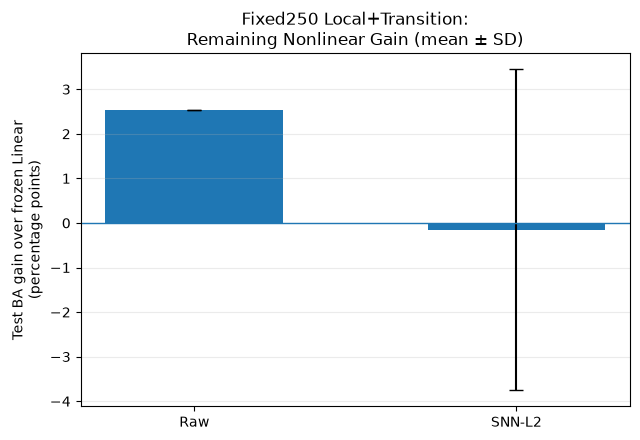

In [7]:
# Fixed250 summary: mean ± SD across frozen SNN seeds

fixed250 = paired_summary[
    paired_summary["temporal_representation"] == "fixed250"
].copy()

display(
    fixed250[
        [
            "decoder",
            "mean_snn_minus_raw_linear_test_ba",
            "sd_snn_minus_raw_linear_test_ba",
            "raw_nonlinear_gain",
            "mean_snn_nonlinear_gain",
            "sd_snn_nonlinear_gain",
            "mean_snn_gain_minus_raw_gain",
            "sd_snn_gain_minus_raw_gain",
            "snn_lower_gain_seeds",
            "snn_linear_better_seeds",
        ]
    ]
)


# ------------------------------------------------------------
# Primary result: Fixed250 + Local+Transition
# Raw nonlinear gain vs SNN-L2 nonlinear gain
# ------------------------------------------------------------

primary = fixed250[
    fixed250["decoder"] == "local_transition"
].iloc[0]

labels = [
    "Raw",
    "SNN-L2",
]

means = np.array(
    [
        primary["raw_nonlinear_gain"],
        primary["mean_snn_nonlinear_gain"],
    ]
) * 100

# Raw is deterministic on the fixed split, so SD = 0.
# SNN-L2 SD is across the 3 frozen SNN seeds.
sds = np.array(
    [
        0.0,
        primary["sd_snn_nonlinear_gain"],
    ]
) * 100


fig, ax = plt.subplots(figsize=(6.5, 4.5))

x = np.arange(len(labels))

ax.bar(
    x,
    means,
    yerr=sds,
    capsize=5,
    width=0.55,
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_xticks(
    x,
    labels,
)

ax.set_ylabel(
    "Test BA gain over frozen Linear\n"
    "(percentage points)"
)

ax.set_title(
    "Fixed250 Local+Transition:\n"
    "Remaining Nonlinear Gain (mean ± SD)"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

plt.show()

## 3. Local vs Transition and Relative10 controls


In [4]:
display(paired_summary[paired_summary['temporal_representation'] == 'fixed250'])
display(paired_summary[paired_summary['temporal_representation'] == 'relative10'])


,temporal_representation,decoder,n_snn_seeds,mean_snn_minus_raw_linear_test_ba,sd_snn_minus_raw_linear_test_ba,raw_nonlinear_gain,mean_snn_nonlinear_gain,sd_snn_nonlinear_gain,mean_snn_gain_minus_raw_gain,sd_snn_gain_minus_raw_gain,snn_lower_gain_seeds,snn_linear_better_seeds
0,fixed250,local,3,0.07747,0.023422,0.000000,0.014745,0.015283,0.014745,0.015283,1,3
1,fixed250,local_transition,3,0.07747,0.023422,0.025433,-0.001550,0.036003,-0.026983,0.036003,2,3
2,fixed250,transition,3,0.07747,0.023422,0.012994,0.007858,0.017318,-0.005136,0.017318,1,3


,temporal_representation,decoder,n_snn_seeds,mean_snn_minus_raw_linear_test_ba,sd_snn_minus_raw_linear_test_ba,raw_nonlinear_gain,mean_snn_nonlinear_gain,sd_snn_nonlinear_gain,mean_snn_gain_minus_raw_gain,sd_snn_gain_minus_raw_gain,snn_lower_gain_seeds,snn_linear_better_seeds
3,relative10,local,3,-0.057481,0.035447,0.029264,-0.022117,0.032785,-0.051381,0.032785,3,0
4,relative10,local_transition,3,-0.057481,0.035447,0.016367,-0.008978,0.025570,-0.025345,0.025570,2,0
5,relative10,transition,3,-0.057481,0.035447,0.004870,-0.002642,0.022822,-0.007513,0.022822,1,0


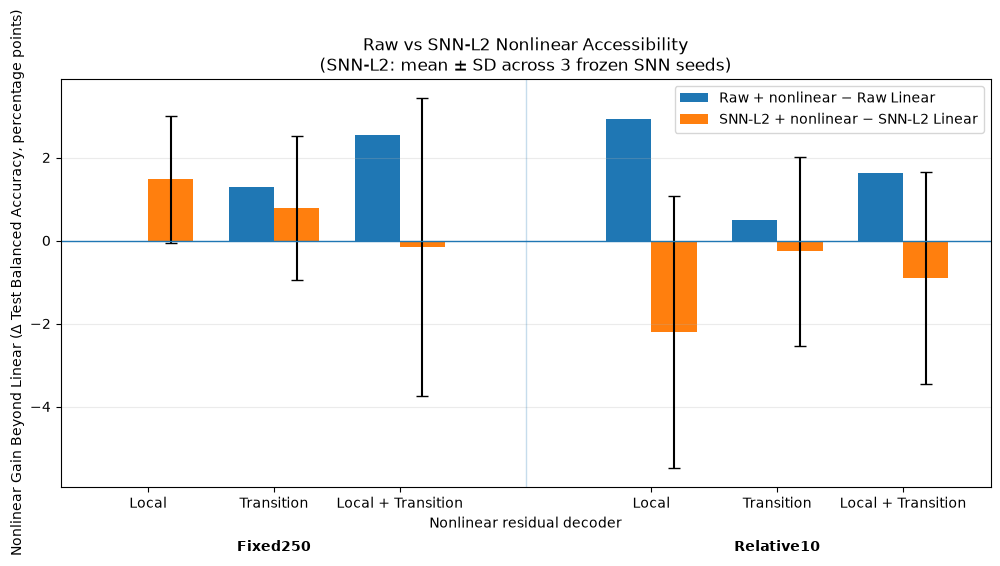

In [5]:
# Visualize Experiment 3.3 paired summary:
# Raw nonlinear gain vs SNN-L2 nonlinear gain
# for Fixed250 and Relative10 across Local / Transition / Local+Transition.
#
# Assumes `paired_summary` is already loaded by the notebook.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


representation_order = ["fixed250", "relative10"]
decoder_order = ["local", "transition", "local_transition"]

representation_labels = {
    "fixed250": "Fixed250",
    "relative10": "Relative10",
}

decoder_labels = {
    "local": "Local",
    "transition": "Transition",
    "local_transition": "Local + Transition",
}


# ================================================================
# Prepare data
# ================================================================

plot_df = paired_summary[
    paired_summary["temporal_representation"].isin(representation_order)
    & paired_summary["decoder"].isin(decoder_order)
].copy()

plot_df["temporal_representation"] = pd.Categorical(
    plot_df["temporal_representation"],
    categories=representation_order,
    ordered=True,
)

plot_df["decoder"] = pd.Categorical(
    plot_df["decoder"],
    categories=decoder_order,
    ordered=True,
)

plot_df = (
    plot_df
    .sort_values(["temporal_representation", "decoder"])
    .reset_index(drop=True)
)


# ================================================================
# Build x-axis:
#
# Fixed250:
#   Local | Transition | Local + Transition
#
# Relative10:
#   Local | Transition | Local + Transition
# ================================================================

group_gap = 1.0

x_positions = []
x_labels = []
representation_centers = {}

current_x = 0.0

for representation in representation_order:
    rep_positions = []

    for decoder in decoder_order:
        x_positions.append(current_x)
        rep_positions.append(current_x)
        x_labels.append(decoder_labels[decoder])
        current_x += 1.0

    representation_centers[representation] = np.mean(rep_positions)
    current_x += group_gap

x_positions = np.asarray(x_positions)


# ================================================================
# Extract values
# ================================================================

raw_gain = 100 * plot_df["raw_nonlinear_gain"].to_numpy()

snn_gain = 100 * plot_df["mean_snn_nonlinear_gain"].to_numpy()

snn_gain_sd = 100 * plot_df["sd_snn_nonlinear_gain"].to_numpy()


# ================================================================
# Plot Raw vs SNN-L2 nonlinear gain
# ================================================================

fig, ax = plt.subplots(figsize=(12.0, 6.0))

bar_width = 0.36

ax.bar(
    x_positions - bar_width / 2,
    raw_gain,
    width=bar_width,
    label="Raw + nonlinear − Raw Linear",
)

ax.bar(
    x_positions + bar_width / 2,
    snn_gain,
    width=bar_width,
    yerr=snn_gain_sd,
    capsize=4,
    label="SNN-L2 + nonlinear − SNN-L2 Linear",
)


# Zero = nonlinear decoder adds nothing beyond Linear
ax.axhline(
    0.0,
    linewidth=1.0,
)


# ================================================================
# X labels
# ================================================================

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)


# Representation labels below decoder labels
for representation in representation_order:
    ax.text(
        representation_centers[representation],
        -0.13,
        representation_labels[representation],
        ha="center",
        va="top",
        transform=ax.get_xaxis_transform(),
        fontweight="bold",
    )


# Vertical separator between Fixed250 and Relative10
separator_x = (
    x_positions[len(decoder_order) - 1]
    + x_positions[len(decoder_order)]
) / 2

ax.axvline(
    separator_x,
    linewidth=1.0,
    alpha=0.25,
)


# ================================================================
# Labels / title
# ================================================================

ax.set_ylabel(
    "Nonlinear Gain Beyond Linear "
    "(Δ Test Balanced Accuracy, percentage points)"
)

ax.set_xlabel("Nonlinear residual decoder")

ax.set_title(
    "Raw vs SNN-L2 Nonlinear Accessibility\n"
    "(SNN-L2: mean ± SD across 3 frozen SNN seeds)"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25,
)

fig.subplots_adjust(
    bottom=0.20,
)

plt.show()

## Conclusion

The conclusion is determined by the pre-registered Fixed250 validation standard rather than chosen after inspecting the results. **SUPPORTED** means Raw has positive Local+Transition nonlinear gain, SNN-L2 is more linearly accessible, and the remaining nonlinear gain is smaller after the frozen SNN in a consistent majority of source seeds. This supports the mechanism that SNN dynamics have linearized part of the useful temporal structure.

If the result is **NOT SUPPORTED**, inspect Local and Transition separately to determine whether the failure comes from absent Raw nonlinear gain, weak SNN linear accessibility, or nonlinear information remaining in the SNN state. Because SNN-L2 has 128 channels versus Raw's 30, a larger SNN residual gain is capacity-confounded and is not by itself evidence for intrinsically more nonlinear information.


In [6]:
status = 'SUPPORTED' if conclusion['primary_hypothesis_supported'] else 'NOT SUPPORTED'
criteria = pd.DataFrame([
    {'criterion': '1. SNN Linear > Raw Linear', 'pass': conclusion['criterion_1_linear_better']},
    {'criterion': '2. Raw nonlinear gain > 0', 'pass': conclusion['criterion_2_raw_has_nonlinear_gain']},
    {'criterion': '3. Mean SNN nonlinear gain < Raw nonlinear gain', 'pass': conclusion['criterion_3_snn_gain_smaller']},
    {'criterion': '4. Smaller SNN gain in at least 2/3 seeds', 'pass': conclusion['criterion_4_consistent_across_seeds']},
])
display(criteria)
text = (
    f'### Final conclusion: **{status}**\n\n'
    f'- Mean Fixed250 SNN-L2 Linear - Raw Linear: **{100 * conclusion["mean_snn_minus_raw_linear_test_ba"]:.2f} pp**\n'
    f'- Raw Fixed250 Local+Transition nonlinear gain: **{100 * conclusion["raw_nonlinear_gain"]:.2f} pp**\n'
    f'- Mean SNN-L2 nonlinear gain: **{100 * conclusion["mean_snn_nonlinear_gain"]:.2f} pp**\n'
    f'- Mean SNN gain - Raw gain: **{100 * conclusion["mean_snn_gain_minus_raw_gain"]:.2f} pp**\n'
    f'- Smaller nonlinear gain in SNN seeds: **{conclusion["snn_lower_gain_seeds"]}/{conclusion["n_snn_seeds"]}**'
)
display(Markdown(text))


,criterion,pass
0,1. SNN Linear > Raw Linear,True
1,2. Raw nonlinear gain > 0,True
2,3. Mean SNN nonlinear gain < Raw nonlinear gain,True
3,4. Smaller SNN gain in at least 2/3 seeds,True


### Final conclusion: **SUPPORTED**

- Mean Fixed250 SNN-L2 Linear - Raw Linear: **7.75 pp**
- Raw Fixed250 Local+Transition nonlinear gain: **2.54 pp**
- Mean SNN-L2 nonlinear gain: **-0.15 pp**
- Mean SNN gain - Raw gain: **-2.70 pp**
- Smaller nonlinear gain in SNN seeds: **2/3**